# Kaggle Opdracht

### Setup

In [209]:
import pandas as pd
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree


In [ ]:

df = pd.read_csv("../Data/HulpmiddelenBS/student_data.csv", sep=",")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

De dataset bestaat uit de volgende kolommen.
 - __school__ = Type school  
            *('GP' - Gabriel Pereira or 'MS' - Mousinho da Silveira)*
- __sex__ = Geslacht  
            *('F' - female or 'M' - male)*
- __age__ = Leeftijd  
            *(15 to 22)*
- __address__ = Huisadres  
            *('U' - urban or 'R' - rural)*
- __famsize__ = Grootte van het gezin  
            *('LE3' - less or equal to 3 or 'GT3' - greater than 3)*
- __Pstatus__ = Samenlevingsstatus van de ouders  
            *('T' - living together or 'A' - apart)*
- __Medu__ = Opleiding van moeder  
            *(0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)*
- __Fedu__ = Opleiding van vader  
            *(0 - none, 1 - primary education (4th grade), 2 - 5th to 9th grade, 3 - secondary education or 4 - higher education)*
- __Mjob__ = Baan van moeder  
            *('teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')*
- __Fjob__ = Baan van vader  
            *('teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')*
- __reason__ = Reden om voor deze school te kiezen  
            *(close to 'home', school 'reputation', 'course' preference or 'other')*
- __guardian__ = Voogd  
            *('mother', 'father' or 'other')*
- __traveltime__ = Reistijd  
            *(1 - <15 min., 2 - 15 to 30 min., 3 - 30 min. to 1 hour, or 4 - >1 hour)*
- __studytime__ = Hoeveelheid tijd de student weekelijks besteed aan leren  
            *(1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - 10 hours)*
- __failures__ = Aantal gefaalde klassen  
            *(n if 1<=n<3, else 4)*
- __schoolsup__ = Has school support  
            *(yes or no)*
- __famsup__ = educatieven ondersteuning van het gezin  
            *(yes or no)*
- __paid__ = extra betaalde lessen binnen het vak Wiskunde of Portugees  
            *(yes or no)*
- __activities__ = Buitenschoolse activiteiten  
            *(yes or no)*
- __nursery__ = Is op de basisschool gezeten  
            *(yes or no)*
- __higher__ = Wilt het hoger ondeerwijs volgen  
            *(yes or no)*
- __internet__ = Heeft thuis beschikking tot het internet  
            *(yes or no)*
- __romantic__ = Heeft een romantische relatie  
            *(yes or no)*
- __famrel__ = Heeft goede relatie met familie  
            *(from 1 - very bad to 5 - excellent)*
- __freetime__ = Hoeveelheid vrije tijd na school  
            *(from 1 - very low to 5 - very high)*
- __goout__ = Gaat uit met vrienden  
            *(from 1 - very low to 5 - very high)*
- __Dalc__ = Drinkt alcohol op een werkdag  
            *(from 1 - very low to 5 - very high)*
- __Walc__ = Drinkt alcohol in het weekend  
            *(from 1 - very low to 5 - very high)*
- __health__ = Huidige gezondheid  
            *(from 1 - very low to 5 - very high)*
- __absences__ = Aantal afwezigheden  
            *(from 0 to 93)*
- __G1__ = Cijfer 1e periode  
            *(from 0 to 20)*
- __G2__ = Cijfer 2e periode  
            *(from 0 to 20)*
- __G3__ = Cijfer 3e periode  
            *(from 0 to 20)*

## Linear Regression

### Aanmaken van de Dataframe

In [211]:
df = df.loc[:, ['G1', 'G2', 'G3', 'studytime', 'failures', 'absences', 'Medu', 'Fedu']]
df

,G1,G2,G3,studytime,failures,absences,Medu,Fedu
0,5,6,6,2,0,6,4,4
1,5,5,6,2,0,4,1,1
2,7,8,10,2,3,10,1,1
3,15,14,15,3,0,2,4,2
4,6,10,10,2,0,4,3,3
...,...,...,...,...,...,...,...,...
390,9,9,9,2,2,11,2,2
391,14,16,16,1,0,3,3,1
392,10,8,7,1,3,3,1,1
393,11,12,10,1,0,0,3,2


### Horizontaal en verticaal snijden  
__X-as__ met de features (G1, G2, studytime, failures, absences, Medu, Fedu)  
__y-as__ met de target (In dit geval G3)

In [212]:
X = df.drop('G3', axis=1)
y = df.loc[:, ['G3']]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size= 0.15,
    random_state=42
)

### Regressie Model

In [214]:
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

prediction_df = pd.DataFrame(y_pred)
prediction_df = prediction_df.rename(columns = {0 : 'Predicted_G3'})

y_test_prediction_merge = pd.concat([y_test.reset_index()['G3'], prediction_df], axis = 1)

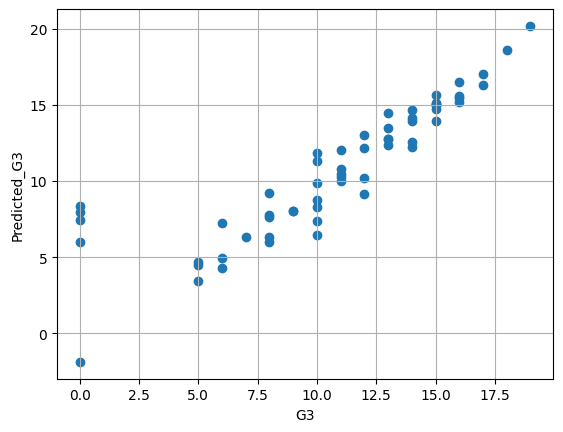

In [216]:
plt.scatter(y_test_prediction_merge['G3'], y_test_prediction_merge['Predicted_G3'])
plt.xlabel('G3')
plt.ylabel('Predicted_G3')
plt.grid(True)
plt.show()

In [217]:
mse = mean_squared_error(y_test_prediction_merge['G3'], y_test_prediction_merge['Predicted_G3'])
mae = mean_absolute_error(y_test_prediction_merge['G3'], y_test_prediction_merge['Predicted_G3'])

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Squared Error (MSE): 5.11
Mean Absolute Error (MAE): 1.37


## Random forest classifier

### Trainen van het model

In [218]:
tree_model = RandomForestClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_tree_pred = tree_model.predict(X_test)
mse_tree = mean_squared_error(y_test, y_tree_pred)
mae_tree = mean_absolute_error(y_test, y_tree_pred)
r2_tree = r2_score(y_test, y_tree_pred)

/home/mark/VSCode/DEDSPortfolio/.venv/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [219]:
print(f"Mean Squared Error: {mse_tree:.2f}")
print(f"Mean Absolute Error: {mae_tree:.2f}")
print(f"R²-score: {r2_tree:.2f}")

Mean Squared Error: 4.42
Mean Absolute Error: 1.08
R²-score: 0.80
